In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
from apps.onpe.client import headers, cookies, get_resultados_onpe
from pydantic import BaseModel, computed_field, ConfigDict, Field, model_validator
from typing import Annotated, Self, Literal
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from apps.onpe.enums import Eleccion, AmbitoGeografico, UbigeoNivel1, TipoFiltro, UbigeoNivel2
from apps.onpe.schemas import ConsultaElectoral
import re
import pandas as pd
from core.settings import settings
from enum import Enum

In [42]:
all_data = []

for ubigeo in UbigeoNivel2:
    consulta_electoral = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL, ubigeo_2=ubigeo)
    data_resumen = get_resultados_onpe(consulta_electoral, mode='resumen')['data']
    data_detalle = get_resultados_onpe(consulta_electoral, mode='detalle')['data']
    actas_contabilizadas_porcentaje = data_resumen['actasContabilizadas']

    if actas_contabilizadas_porcentaje <= 8:
        print(f"Ubigeo {ubigeo.name}: No se han contabilizado actas aún. Proyectando resultados...")
        total_actas = data_resumen['totalActas']

        # Calcular segun ubigeo nivel 1
        ubigeo_nivel_1 = ubigeo.nivel1
        consulta_ubigeo_nivel_1 = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL, ubigeo=ubigeo_nivel_1)
        nivel_1_resumen = get_resultados_onpe(consulta_ubigeo_nivel_1, mode='resumen')['data']
        nivel_1_detalle = get_resultados_onpe(consulta_ubigeo_nivel_1, mode='detalle')['data']

        nivel_1_actas_porcentaje = nivel_1_resumen['actasContabilizadas']
        nivel_1_jp_votos = next(d['totalVotosValidos'] for d in nivel_1_detalle if d['nombreAgrupacionPolitica'] == 'JUNTOS POR EL PERÚ')
        nivel_1_porky_votos = next(d['totalVotosValidos'] for d in nivel_1_detalle if d['nombreAgrupacionPolitica'] == 'RENOVACIÓN POPULAR')

        nivel_1_jp_votos_proyectados = int(nivel_1_jp_votos / nivel_1_actas_porcentaje * 100)
        nivel_1_porky_votos_proyectados = int(nivel_1_porky_votos / nivel_1_actas_porcentaje * 100)

        total_actas_nivel_1 = nivel_1_resumen['totalActas']

        nivel_2_jp_votos_proyectados = int(nivel_1_jp_votos_proyectados / total_actas_nivel_1 * total_actas)
        nivel_2_porky_votos_proyectados = int(nivel_1_porky_votos_proyectados / total_actas_nivel_1 * total_actas)

        jp_data = {
            'nombreAgrupacionPolitica': 'JUNTOS POR EL PERÚ',
            'ubigeo1': ubigeo_nivel_1.name,
            'ubigeo2': ubigeo.name,
            'actualVotosValidos': nivel_2_jp_votos_proyectados,
            'proyeccionVotosValidos': nivel_2_jp_votos_proyectados
        }

        porky_data = {
            'nombreAgrupacionPolitica': 'RENOVACIÓN POPULAR',
            'ubigeo1': ubigeo_nivel_1.name,
            'ubigeo2': ubigeo.name,
            'actualVotosValidos': nivel_2_porky_votos_proyectados,
            'proyeccionVotosValidos': nivel_2_porky_votos_proyectados
        }
        all_data.extend([jp_data, porky_data])
        continue

    data_for_extend = [{
        'nombreAgrupacionPolitica': data['nombreAgrupacionPolitica'],
        'ubigeo1': consulta_electoral.ubigeo.name,
        'ubigeo2': consulta_electoral.ubigeo_2.name,
        'actualVotosValidos': data['totalVotosValidos'],
        'proyeccionVotosValidos': int(data['totalVotosValidos'] / actas_contabilizadas_porcentaje * 100)
    } for data in data_detalle]
    all_data.extend(data_for_extend)
    print(f"{len(all_data)} registros procesados")

df_proyeccion = pd.DataFrame(all_data)

38 registros procesados
76 registros procesados
114 registros procesados
152 registros procesados
190 registros procesados
228 registros procesados
266 registros procesados
304 registros procesados
342 registros procesados
380 registros procesados
418 registros procesados
456 registros procesados
494 registros procesados
532 registros procesados
570 registros procesados
608 registros procesados
646 registros procesados
684 registros procesados
722 registros procesados
760 registros procesados
798 registros procesados
836 registros procesados
874 registros procesados
912 registros procesados
950 registros procesados
988 registros procesados
1026 registros procesados
1064 registros procesados
1102 registros procesados
1140 registros procesados
1178 registros procesados
1216 registros procesados
1254 registros procesados
1292 registros procesados
1330 registros procesados
1368 registros procesados
1406 registros procesados
1444 registros procesados
1482 registros procesados
1520 registros

In [43]:
df_final = df_proyeccion.groupby('nombreAgrupacionPolitica').sum(numeric_only=True).sort_values('proyeccionVotosValidos', ascending=False)
df_final.drop(index=['VOTOS EN BLANCO', 'VOTOS NULOS'], inplace=True)
df_final['porcentaje_final'] = df_final['proyeccionVotosValidos'] / df_final['proyeccionVotosValidos'].sum() * 100

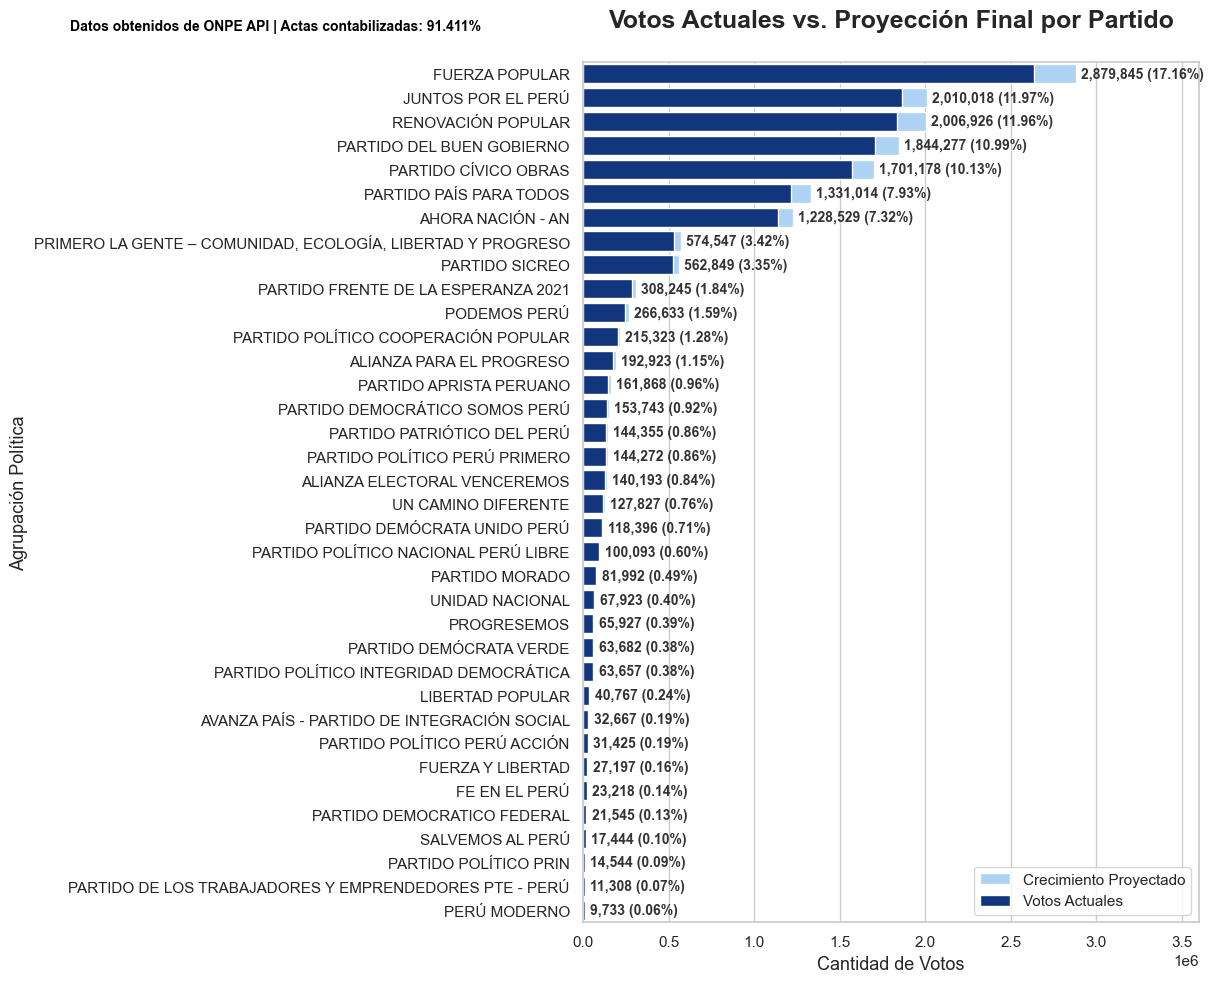

: 

In [ ]:
consulta_total = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL)
resumen_total = get_resultados_onpe(consulta_total, mode="resumen")['data']
actas_contabilizadas_total = resumen_total['actasContabilizadas']

# 1. Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10)) # Aumentamos un poco el ancho para que quepan las etiquetas

# 2. Dibujamos la barra de PROYECCIÓN (Fondo - el total esperado)
ax = sns.barplot(
    data=df_final,
    x='proyeccionVotosValidos',
    y='nombreAgrupacionPolitica',
    color='#A2D2FF',  # Azul claro
    label='Crecimiento Proyectado'
)

# 3. Dibujamos la barra de VOTOS ACTUALES (Encima)
sns.barplot(
    data=df_final,
    x='actualVotosValidos',
    y='nombreAgrupacionPolitica',
    color='#00308F',  # Azul oscuro
    label='Votos Actuales'
)

# 4. Personalización de etiquetas y títulos
plt.title('Votos Actuales vs. Proyección Final por Partido', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Cantidad de Votos', fontsize=13)
plt.ylabel('Agrupación Política', fontsize=13)
plt.legend(loc='lower right', frameon=True)

# 5. Añadir el texto: "Votos Totales (Porcentaje%)"
# Usamos f-strings para formatear los números con comas como separadores de miles
for i, row in enumerate(df_final.itertuples()):
    votos_totales = getattr(row, 'proyeccionVotosValidos')
    porcentaje = getattr(row, 'porcentaje_final')
    
    label_text = f'{votos_totales:,.0f} ({porcentaje:.2f}%)'
    
    plt.text(
        votos_totales + (df_final['proyeccionVotosValidos'].max() * 0.01), # Un pequeño margen a la derecha
        i, 
        label_text, 
        va='center', 
        fontsize=10, 
        fontweight='bold',
        color='#333333'
    )

plt.text(-0.5, 1.05, f"Datos obtenidos de ONPE API | Actas contabilizadas: {actas_contabilizadas_total}%",
        transform=ax.transAxes, # Usar coordenadas de ejes para que no se mueva
        ha='center', va='top', 
        fontsize=10, 
        color='black',
        fontweight='bold')

# Ajustar los límites del eje X para que las etiquetas no se corten
plt.xlim(0, df_final['proyeccionVotosValidos'].max() * 1.25)

plt.tight_layout()
plt.show()